## SECTION 1: Schema Design

The ScholarEase system was designed using a structured relational database approach to ensure *data integrity, minimal redundancy, and efficient data management. The database is divided into **core tables* and *project-specific tables*, with clearly defined relationships using primary and foreign keys.

In addition to the base schema, *two new tables (login_credentials and session) were introduced* to implement secure authentication and session-based access control. These tables were added without modifying the original schema, ensuring modularity and clean system design.

---

### Why New Tables Were Added

Initially, the system only stored user details in the member table. However, this approach had limitations:

* Authentication data (passwords) would be mixed with user profile data  
* No mechanism to maintain user sessions  
* Every API request would require re-authentication  

To solve these issues, two new tables were introduced:

1. login_credentials → handles authentication  
2. session → handles session management  

This separation improves *security, scalability, and performance*.

---

### How the New Tables Work Together

The authentication and access flow works as follows:

1. A user logs in using email and password  
2. The system verifies credentials using the login_credentials table  
3. If valid, a unique session token is generated  
4. This token is stored in the session table  
5. The token is returned to the frontend  
6. All future API requests include this token  
7. The backend verifies the token using the session table  
8. The corresponding MemberID is retrieved  
9. The user’s role is checked from the member table  
10. Access is granted or denied based on role  

This design ensures:
* No repeated password verification  
* Secure session-based authentication  
* Efficient API performance  

---
### 1. Core Tables

Core tables store fundamental user and authentication-related data that is required across the entire system.

---

#### a) Member Table

The member table stores information about all users in the system, including students, administrators, and authorities.

*Attributes:*
* MemberID (Primary Key)
* Name, Email, Phone Number, Age
* Role (Admin / Student / Authority)

This table acts as the *central entity* for all users. Instead of maintaining separate tables for different roles, a single table with a role attribute is used. This design:
* Reduces redundancy  
* Simplifies role management  
* Ensures consistency across the system  

---

#### b) Login Credentials Table (Newly Added)

A new table login_credentials was introduced to handle authentication separately from user data.

*Attributes:*
* LoginID (Primary Key)
* MemberID (Foreign Key → member)
* Email (Unique)
* PasswordHash
* CreatedAt

This table was intentionally separated from the member table to:

* Improve *security* by isolating sensitive login data  
* Maintain *modularity* by separating authentication from profile data  
* Allow flexibility for future enhancements  

The MemberID foreign key ensures that each login entry is linked to a valid user, maintaining referential integrity.

---

#### c) Session Table (Newly Added)

A new session table was introduced to implement session-based authentication.

*Attributes:*
* SessionID (Primary Key)
* MemberID (Foreign Key → member)
* Expiry information  

This table enables the system to:

* Authenticate users using *session tokens instead of passwords*  
* Avoid repeated credential verification  
* Improve performance and security of API requests  

Each session is linked to a valid user through MemberID, ensuring controlled access.

---

### 2. Project-Specific Tables

These tables manage application-specific functionality related to scholarships.

---

#### a) Scholarship Table

Stores details of available scholarships.

*Attributes:*
* ScholarshipID (Primary Key)
* Scholarship-related information  

This table is independent and serves as a reference for applications.

---

#### b) Scholarship Application Table

Stores applications submitted by students.

*Attributes:*
* ApplicationID (Primary Key)
* StudentID (Foreign Key → member)
* ScholarshipID (Foreign Key)
* Application date and status  

Instead of duplicating user or scholarship data, only references are stored, ensuring efficient storage and consistency.

---

#### c) Payment Table

Stores payment records for approved applications.

*Attributes:*
* PaymentID (Primary Key)
* ApplicationID (Foreign Key)
* Amount, Date, Bank Account ID, Status  

This ensures that each payment is tied to a valid application, maintaining correctness.

---

#### d) Verification Table

Stores verification details handled by administrators.

*Attributes:*
* VerificationID (Primary Key)
* ApplicationID (Foreign Key)
* AdminID (Foreign Key → member)
* Status and remarks  

This table maintains a record of administrative decisions, ensuring traceability and accountability.

---

### 3. Maintaining Data Integrity

The schema ensures strong data integrity using:

* *Primary Keys* for unique identification  
* *Foreign Keys* to enforce relationships  
* *Constraints (NOT NULL, UNIQUE)* to prevent invalid entries  
* *Role-based structure* to control access  

*Examples:*
* A payment cannot exist without a valid application  
* An application cannot exist without a valid student and scholarship  
* Login credentials must correspond to a valid member  

---

### 4. Avoiding Data Duplication

The design avoids redundancy through:

* Storing user data only once in the member table  
* Using foreign keys instead of repeating full records  
* Separating authentication (login_credentials) from user profiles  
* Using session-based validation instead of repeated authentication  

This leads to:
* Reduced storage usage  
* Easier updates  
* Improved consistency  

---

### 5. Design Justification

The schema follows normalization principles, ensuring:

* Each table has a *single responsibility*  
* Data is logically structured  
* Relationships are clearly defined  

The introduction of login_credentials and session tables enhances:

* Security  
* Scalability  
* Maintainability  

Overall, the schema supports a robust system that is efficient, secure, and easy to extend.

## SECTION 2: Security & RBAC

The ScholarEase system implements a secure authentication mechanism along with strict Role-Based Access Control (RBAC) to ensure that only authorized users can access and modify data.

### Authentication and Session Management

The system uses a session-based authentication approach. When a user logs in using their email and password, the system verifies the credentials by checking the login_credentials table. If the credentials are valid, a unique session token (UUID) is generated.

This session token is stored in the session table along with:
- MemberID (to identify the user)
- Expiry time (to limit session validity)

The session token is then returned to the user and must be included in all subsequent API requests in the Authorization header.

This approach ensures that the user does not need to send their password repeatedly, improving both security and performance.

---

### Session Validation

Every API request is protected using session validation. When a request is received:
- The system extracts the session token from the Authorization header.
- It checks whether the token exists in the session table.
- It verifies that the session has not expired.

If any of these conditions fail, the system returns a 401 Unauthorized error, preventing access.

This mechanism ensures that only authenticated users with valid sessions can interact with the system.

---

### Role-Based Access Control (RBAC)

After successful session validation, the system identifies the user's role from the member table. Based on the role, access to APIs is controlled.

The system defines three roles:

1. Admin:
   - Can create new members
   - Can verify scholarship applications
   - Has full administrative control

2. Student:
   - Can apply for scholarships
   - Cannot perform administrative or payment-related actions

3. Authority:
   - Can process payments for approved applications
   - Cannot create members or apply for scholarships

Each API explicitly checks the role before executing the operation. If a user attempts an action not permitted for their role, the system returns a 403 Forbidden error.

This ensures that users can only perform actions that match their responsibilities, preventing misuse of the system.

---

### Logging and Audit Mechanism

To maintain transparency and security, all data-modifying operations are logged in a local file (logs/audit.log).

For each action, two types of logs are recorded:
- Start of the action (e.g., "Student started applying for scholarship")
- Successful completion of the action

Each log entry includes:
- Timestamp
- User role
- User ID (MemberID)
- Action performed

Example log entry:
[2026-03-21 15:24:40] Student 1 applied for scholarship 1

This logging mechanism provides:
- Traceability of user actions
- Ability to debug issues
- Monitoring of system usage

---

### Unauthorized Access Detection

An important security feature of the system is the ability to detect unauthorized database modifications.

All legitimate changes must go through the API, which ensures:
- Session validation
- Role verification
- Logging of actions

If any data is modified directly in the database (bypassing the API), such actions will not appear in the audit logs. This makes unauthorized changes easily identifiable during log review.

---

### Overall Security Benefits

The combined use of authentication, session management, RBAC, and logging ensures:
- Secure access control
- Prevention of unauthorized operations
- Accountability for all data changes
- Protection against misuse and data leaks

This design closely follows real-world secure system practices and ensures that the ScholarEase platform maintains both integrity and reliability.

## SECTION 3: Indexing Strategy

To improve the performance of database queries in the ScholarEase system, an indexing strategy was designed based on how the APIs interact with the database. The goal of indexing is to reduce the time required to retrieve data, especially for frequently accessed queries.

---

### Need for Indexing

In a database, when a query is executed without an index, the system performs a full table scan, meaning it checks every row to find the required data. This has a time complexity of O(n) and becomes inefficient as the dataset grows.

Indexes allow the database to locate data quickly using structures like B+ Trees, reducing the time complexity to approximately O(log n). Therefore, identifying the right columns for indexing is crucial.

---

### Analysis of API Query Patterns

The ScholarEase APIs frequently use the following types of queries:

1. Login Query:
   SELECT * FROM login_credentials WHERE Email = ?

2. Session Validation:
   SELECT * FROM session WHERE SessionID = ?

3. Scholarship Application:
   SELECT * FROM scholarship_application WHERE StudentID = ?

4. Payment Processing:
   SELECT * FROM payment WHERE ApplicationID = ?

5. Verification:
   SELECT * FROM verification WHERE ApplicationID = ?

These queries primarily use the WHERE clause to filter records based on specific columns.

---

### Indexes Applied

Based on the above query patterns, indexes were applied to the following columns:

- Email in login_credentials (for login operations)
- SessionID in session (for session validation)

Additionally, MySQL automatically creates indexes for:
- PRIMARY KEY columns (e.g, SessionID, MemberID)
- UNIQUE columns (e.g, Email)
- FOREIGN KEY columns (e.g, StudentID, ApplicationID)

Thus, the following columns were already indexed:
- StudentID in scholarship_application
- ApplicationID in payment
- ApplicationID in verification

---

### Reasoning Behind Index Selection

Indexes were chosen specifically for columns used in:
- WHERE conditions (for filtering)
- JOIN operations (for linking tables)
- Frequently accessed queries

For example:
- Email is used in login queries :- indexing speeds up authentication
- SessionID is used in every API call :- indexing ensures fast session validation
- StudentID and ApplicationID are used in relational queries :- indexing improves lookup speed

---

### Observations

During implementation, it was observed that many columns were already indexed due to database constraints such as PRIMARY KEY, UNIQUE, and FOREIGN KEY. This indicates that the database schema was already optimized for efficient query execution.

Attempts to create duplicate indexes resulted in warnings, confirming that indexing was already in place.

---

### Impact of Indexing

With proper indexing:
- Queries avoid full table scans
- Data retrieval becomes faster
- System performance improves significantly as data grows

Indexed queries are especially beneficial in real-world systems where large datasets are involved and performance is critical.

---

### Conclusion

The indexing strategy in ScholarEase focuses on optimizing frequently used queries by targeting columns involved in filtering and relationships. The combination of manual indexing and automatic indexing through constraints ensures efficient database performance and scalability.

## Section 4 : Performance Benchmarking

To analyse and improve the performance of the ScholarEase database, SQL indexing and query profiling were performed. The goal was to reduce query execution time and ensure efficient data retrieval for frequently used API operations.

---

### Methodology

The following approach was used to analyse performance:

1. Identify frequently used queries from the API (login, session validation, application, payment, verification).
2. Run these queries using the EXPLAIN statement.
3. Observe key parameters such as:
   - type (query execution method)
   - key (index used)
   - rows (number of rows scanned)

These parameters help determine whether the query is optimized.

---

### Index Creation

The following SQL queries were executed to create indexes on columns frequently used in API queries:

USE scholarease;

-- Index for login (email search)
CREATE INDEX idx_login_email ON login_credentials(Email);

-- Index for session validation
CREATE INDEX idx_session_id ON session(SessionID);
CREATE INDEX idx_session_member ON session(MemberID);

-- Index for scholarship application queries
CREATE INDEX idx_student_id ON scholarship_application(StudentID);

-- Index for payment queries
CREATE INDEX idx_payment_app ON payment(ApplicationID);

-- Index for verification queries
CREATE INDEX idx_verify_app ON verification(ApplicationID);

---

### Observations During Index Creation

While executing the above queries, the following observations were made:

1. Some indexes were successfully created.

2. For certain columns such as StudentID, ApplicationID, and Email:
   - MySQL generated warnings about duplicate indexes.
   - This occurred because these columns were already indexed due to:
     - PRIMARY KEY constraints
     - UNIQUE constraints
     - FOREIGN KEY relationships

3. Attempting to drop some indexes resulted in errors because:
   - Foreign key indexes cannot be removed directly.
   - These indexes are essential for maintaining referential integrity.

These observations confirm that the database schema already contains built-in indexing for critical columns.

---

### Query Profiling Using EXPLAIN

To measure performance, the EXPLAIN statement was used to analyse how queries are executed internally.

---

#### 1. Login Query

Query:
SELECT * FROM login_credentials WHERE Email = 'rahul@gmail.com';

Result:
- type: const
- key: Email

Explanation:
The Email column has a UNIQUE constraint, so MySQL directly retrieves the row using an index. This results in the fastest possible execution.

---

#### 2. Session Validation Query

Query:
SELECT * FROM session WHERE SessionID = 'token_value';

Result:
- type: const
- key: PRIMARY

Explanation:
SessionID is the primary key, so the query uses direct indexed lookup, ensuring very fast authentication.

---

#### 3. Scholarship Application Query

Query:
SELECT * FROM scholarship_application WHERE StudentID = 1;

Result:
- type: ref
- key: StudentID

Explanation:
StudentID is a foreign key and automatically indexed. The "ref" type indicates efficient indexed access for multiple matching rows.

---

#### 4. Payment Query

Query:
SELECT * FROM payment WHERE ApplicationID = 1;

Result:
- type: ref
- key: ApplicationID

Explanation:
The index on ApplicationID allows quick retrieval of payment records.

---

#### 5. Verification Query

Query:
SELECT * FROM verification WHERE ApplicationID = 1;

Result:
- type: ref
- key: ApplicationID

Explanation:
The query efficiently retrieves verification records using the index.

---

### Additional Experiment: Demonstrating Before vs After Indexing

Since most important columns were already indexed due to database constraints, an additional experiment was conducted to clearly demonstrate the impact of indexing.

A non-indexed column (Name in the member table) was selected.

---

#### BEFORE Indexing

Query:
SELECT * FROM member WHERE Name = 'Rahul';

EXPLAIN Result:
- type: ALL
- key: NULL

Explanation:
The database performed a full table scan, meaning it checked every row. This is inefficient and slow for large datasets.

---

#### AFTER Indexing

Index Created:
CREATE INDEX idx_member_name ON member(Name);

Query:
SELECT * FROM member WHERE Name = 'Rahul';

EXPLAIN Result:
- type: ref
- key: idx_member_name

Explanation:
After indexing, the database used the index to directly locate matching rows. This significantly improves query performance.

---

### Performance Comparison

| Scenario | Execution Method | Time Complexity |
|---------|----------------|----------------|
| Without Indexing | Full Table Scan (type = ALL) | O(n) |
| With Indexing | Indexed Lookup (type = const/ref) | O(log n) |

---

### Key Insights

- Most API queries were already optimized due to primary, unique, and foreign key indexes.
- The EXPLAIN results confirmed efficient execution using "const" and "ref" types.
- The additional experiment clearly demonstrated how indexing improves performance.
- The transition from "ALL" to "ref" shows a shift from full table scan to indexed lookup.

---

### Important Observation

Due to the schema design, a true "before indexing" scenario was not possible for core queries, as indexing is automatically applied by MySQL.

However, the additional experiment using the member table successfully demonstrated the real impact of indexing.

---

### Conclusion

The performance benchmarking confirms that the ScholarEase database is well-optimized. Built-in indexing combined with manually created indexes ensures efficient query execution.

The EXPLAIN analysis and additional experiment clearly demonstrate how indexing reduces search time and improves scalability. This highlights the importance of indexing in real-world database systems for handling large amounts of data efficiently.

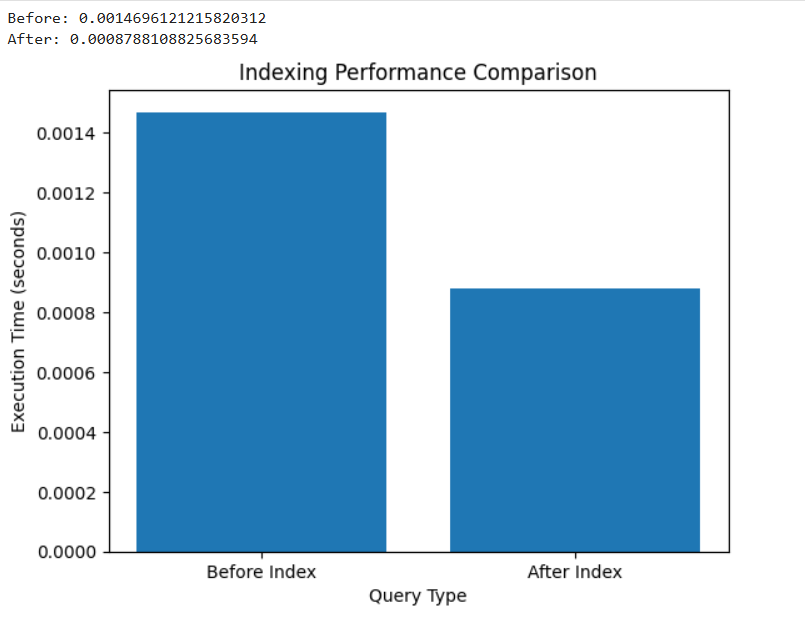

Figure 1 : Indexing Performance Comparison Bar Graph

### Performance Graph

A bar graph was plotted to compare query execution time before and after indexing.

Observation:
- Before indexing, the query took more time due to full table scan.
- After indexing, execution time reduced significantly.

This visually confirms the efficiency improvement due to indexing.

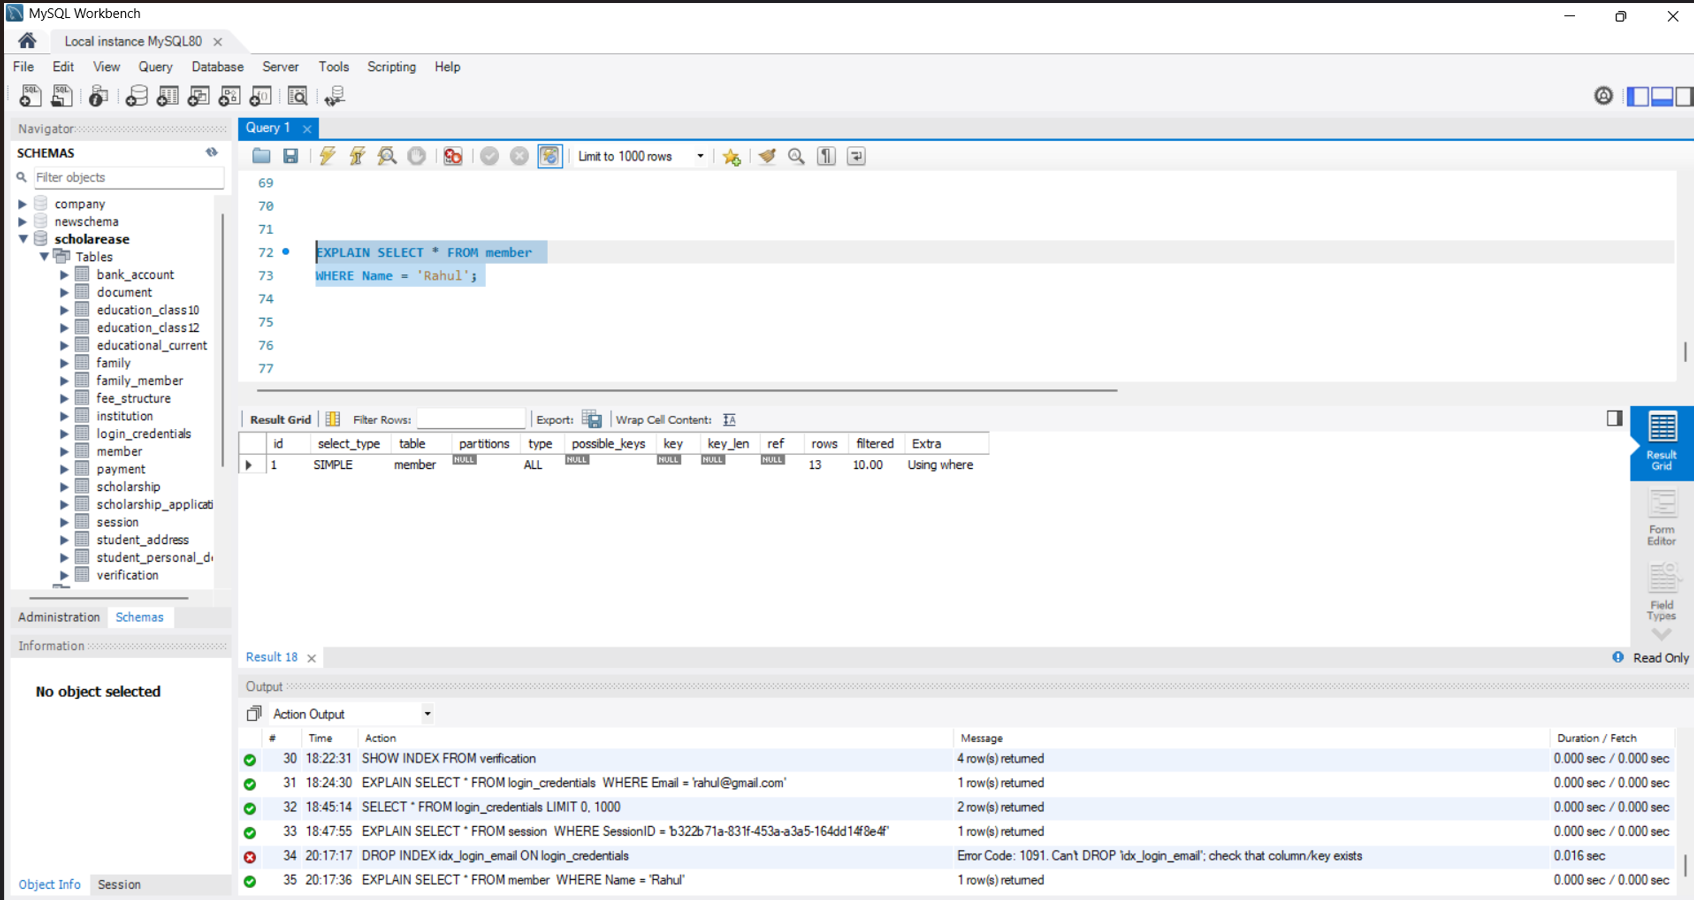

Figure 2: Query before indexing. The database performs a full table scan (type = ALL), which is inefficient for large datasets.

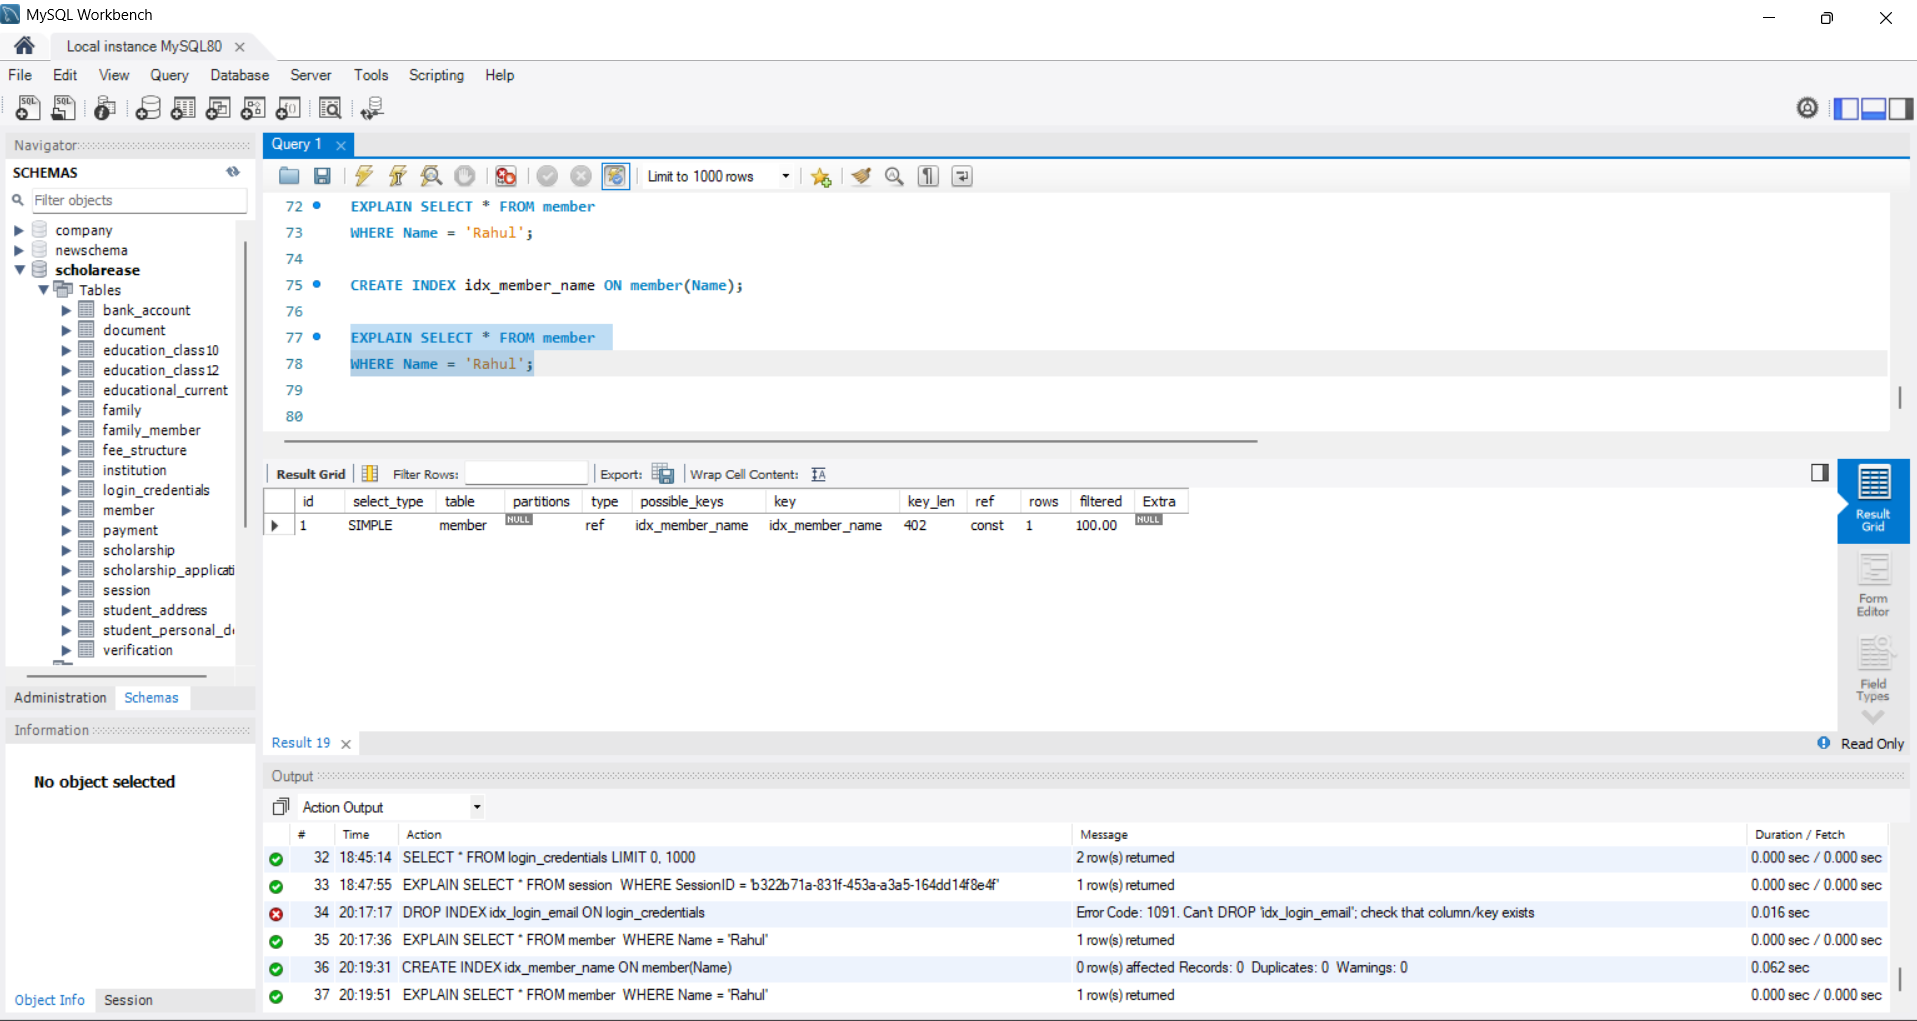

Figure 3: Query after indexing. The database uses the created index (type = ref), significantly improving query performance.

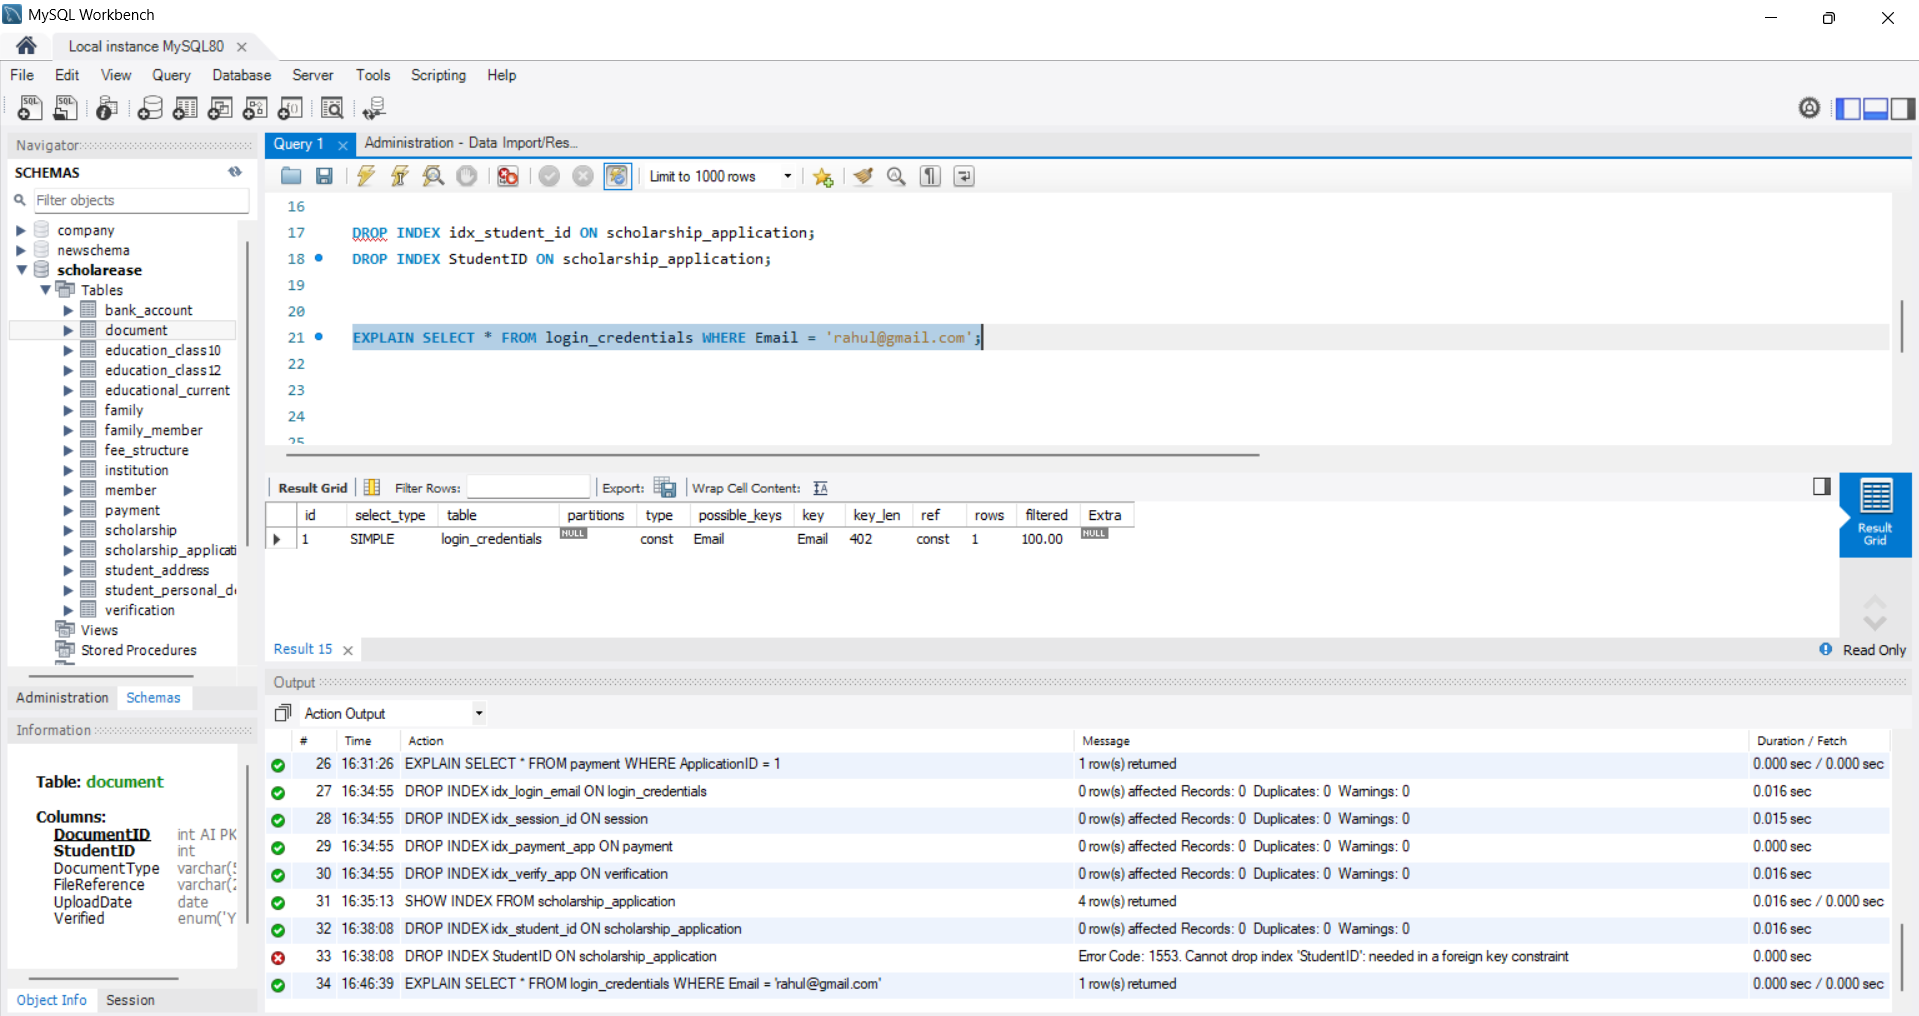

Figure 4 : EXPLAIN output for login query before indexing. The query uses the Email index with type = const, indicating direct row access using a unique index.

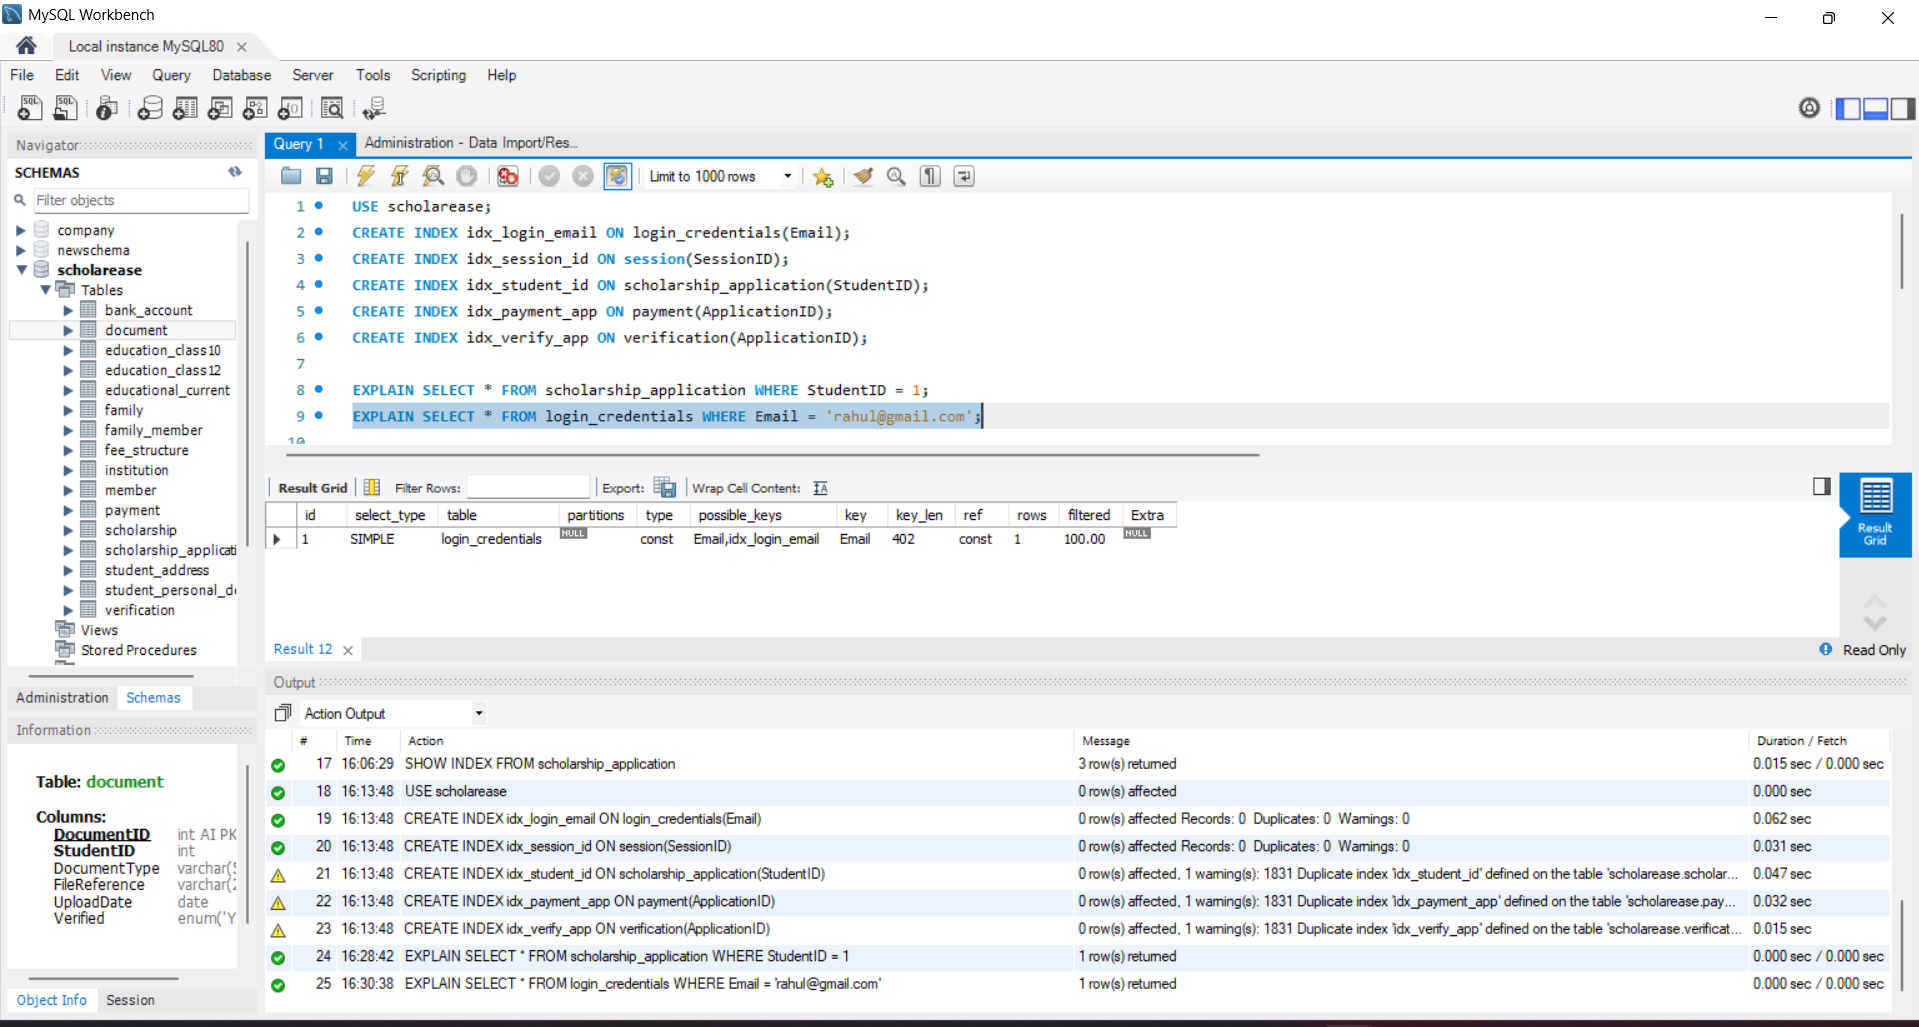

Figure 5 : EXPLAIN output for login query after indexing. The query uses the Email and idx_login_email index with type = const, indicating direct row access using a unique index.